# 01 — EDA
Run one cell at a time. Look at the output. Then move to the next.
Figures are saved to `notebooks/figures/`.

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DB_PATH  = Path('../data/processed/sfu_clean.db')
FIG_PATH = Path('../figures/02_eda')
FIG_PATH.mkdir(exist_ok=True)

assert DB_PATH.exists(), f'not found: {DB_PATH}'
print('ready')

ready


In [2]:
conn = sqlite3.connect(DB_PATH)
df   = pd.read_sql('SELECT * FROM offerings', conn)
conn.close()

print(f'{len(df):,} rows  x  {df.shape[1]} cols')

33,168 rows  x  18 cols


---
## Block 1 — Basic checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33168 entries, 0 to 33167
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   offering_id        33168 non-null  int64 
 1   ml_course_id       33168 non-null  int64 
 2   ml_term_id         33168 non-null  int64 
 3   dept_code          33168 non-null  object
 4   course_number      33168 non-null  object
 5   section_code       33168 non-null  object
 6   instructor         27808 non-null  object
 7   campus             33168 non-null  object
 8   capacity           33168 non-null  int64 
 9   enrolled           33168 non-null  int64 
 10  course_level       33168 non-null  int64 
 11  degree_level       32853 non-null  object
 12  title              33152 non-null  object
 13  year               33168 non-null  int64 
 14  term               33168 non-null  object
 15  term_order         33168 non-null  int64 
 16  semester_code      33168 non-null  int64

In [4]:
df.head(10)

,offering_id,ml_course_id,ml_term_id,dept_code,course_number,section_code,instructor,campus,capacity,enrolled,course_level,degree_level,title,year,term,term_order,semester_code,is_covid_affected
0,2,3,1,ACMA,336,D100,"Erickson, Natalie",Other Vancouver,10,5,300,UGRD,Job Practicum I,2020,spring,1,1201,1
1,3,3,1,ACMA,336,D200,"Erickson, Natalie",Off-campus,10,2,300,UGRD,Job Practicum I,2020,spring,1,1201,1
2,5,4,1,ACMA,337,D100,"Erickson, Natalie",Other Vancouver,10,2,300,UGRD,Job Practicum II,2020,spring,1,1201,1
3,8,5,1,ACMA,340,D100,None,Burnaby,25,12,300,UGRD,Financial Economics for Actuaries,2020,spring,1,1201,1
4,9,6,1,ACMA,360W,D100,"Begin, Jean-Francois; Sanders, Barbara",Burnaby,20,10,300,UGRD,Actuarial Communication,2020,spring,1,1201,1
5,10,9,1,ACMA,436,D100,"Erickson, Natalie",Other Vancouver,10,1,400,UGRD,Job Practicum III,2020,spring,1,1201,1
6,14,10,1,ACMA,437,D200,"Erickson, Natalie",Off-campus,10,1,400,UGRD,Job Practicum IV,2020,spring,1,1201,1
7,23,1941,1,ALS,603,G100,"Hall, Margaret",Surrey,32,23,600,GRAD,Legal Philosophy,2020,spring,1,1201,1
8,24,2300,1,ALS,611,G100,"Usher, Ronald",Surrey,32,23,600,GRAD,Real Property I,2020,spring,1,1201,1
9,25,17,1,ALS,620,G100,"Bowbrick, Graeme",Surrey,32,25,600,GRAD,Selected Topics in Applied Legal Studies,2020,spring,1,1201,1


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.duplicated(subset=['ml_course_id', 'ml_term_id', 'section_code']).sum()

np.int64(0)

In [7]:
df[['enrolled', 'capacity', 'course_level', 'year']].describe().T

,count,mean,std,min,25%,50%,75%,max
enrolled,33168.00,35.34,52.46,1.00,4.00,17.00,40.00,606.00
capacity,33168.00,49.37,62.69,1.00,12.00,30.00,60.00,812.00
course_level,33168.00,440.34,247.06,100.00,300.00,400.00,700.00,900.00
year,33168.00,2022.55,1.71,2020.00,2021.00,2023.00,2024.00,2025.00


In [8]:
df.nlargest(5, 'capacity')[['dept_code', 'course_number', 'section_code', 'capacity', 'enrolled', 'year', 'term']]

,dept_code,course_number,section_code,capacity,enrolled,year,term
3783,CHEM,120,D100,812,515,2020,fall
9172,CHEM,120,D100,660,606,2021,fall
3383,BISC,101,D100,576,567,2020,fall
10268,MATH,154,D100,510,481,2021,fall
4828,MATH,154,D100,507,459,2020,fall


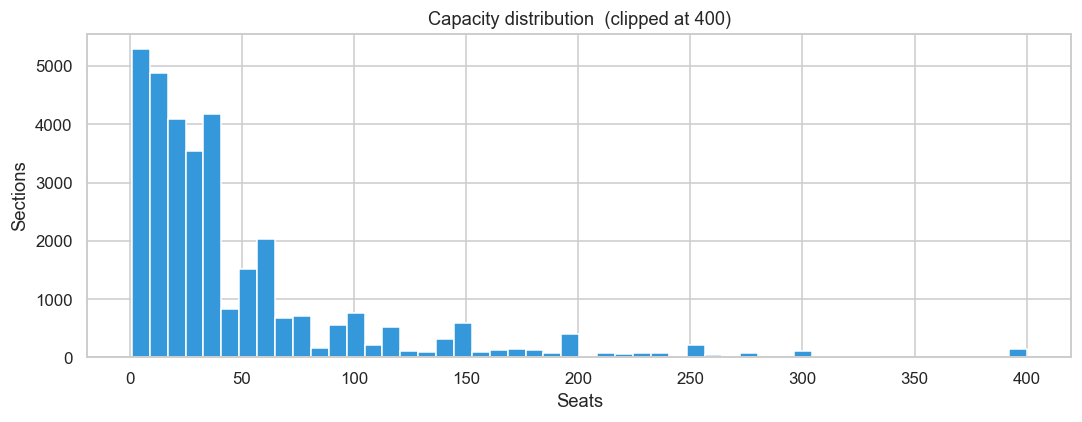

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
df['capacity'].dropna().clip(upper=400).hist(bins=50, ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Capacity distribution  (clipped at 400)')
ax.set_xlabel('Seats')
ax.set_ylabel('Sections')
plt.tight_layout()
plt.savefig(FIG_PATH / '01_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

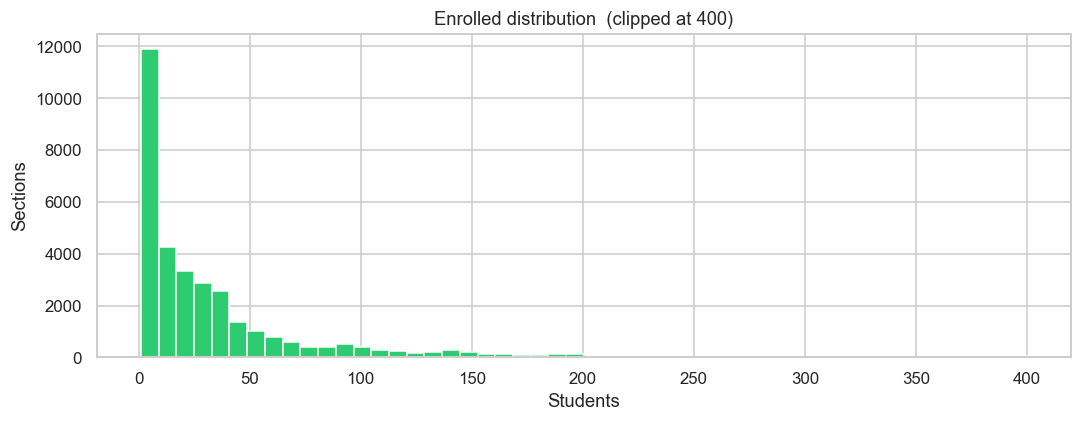

sections with enrolled = 0: 0  (0.0%)
these are offered sections with no students yet — excluded from correlation analysis


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
df['enrolled'].clip(upper=400).hist(bins=50, ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Enrolled distribution  (clipped at 400)')
ax.set_xlabel('Students')
ax.set_ylabel('Sections')
plt.tight_layout()
plt.savefig(FIG_PATH / '02_enrolled.png', dpi=150, bbox_inches='tight')
plt.show()

zero_enroll = (df['enrolled'] == 0).sum()
print(f'sections with enrolled = 0: {zero_enroll:,}  ({zero_enroll/len(df)*100:.1f}%)')
print('these are offered sections with no students yet — excluded from correlation analysis')

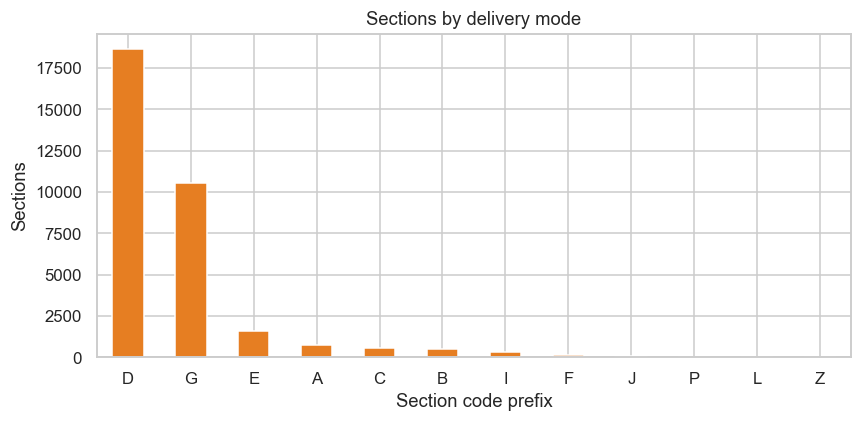

In [11]:
# delivery mode breakdown — D/E/C/F/J/V/O
mode_counts = df['section_code'].str[0].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
mode_counts.plot(kind='bar', ax=ax, color='#e67e22', edgecolor='white')
ax.set_title('Sections by delivery mode')
ax.set_xlabel('Section code prefix')
ax.set_ylabel('Sections')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_PATH / '03_delivery_mode.png', dpi=150, bbox_inches='tight')
plt.show()

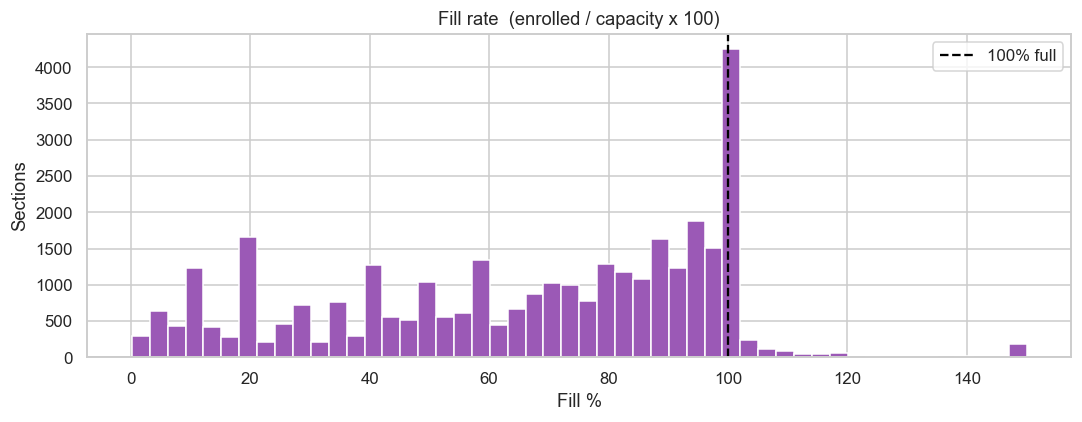

In [12]:
df['fill_rate'] = df['enrolled'] / df['capacity'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
df['fill_rate'].clip(upper=150).hist(bins=50, ax=ax, color='#9b59b6', edgecolor='white')
ax.axvline(100, color='black', linestyle='--', linewidth=1.5, label='100% full')
ax.set_title('Fill rate  (enrolled / capacity x 100)')
ax.set_xlabel('Fill %')
ax.set_ylabel('Sections')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_PATH / '04_fill_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
over = df[df['fill_rate'] > 100]
print(f'over-enrolled sections: {len(over):,}  ({len(over)/len(df)*100:.1f}%)')
print(f'mean fill rate:         {df["fill_rate"].mean():.1f}%')
print(f'median fill rate:       {df["fill_rate"].median():.1f}%')

over-enrolled sections: 933  (2.8%)
mean fill rate:         66.4%
median fill rate:       72.5%


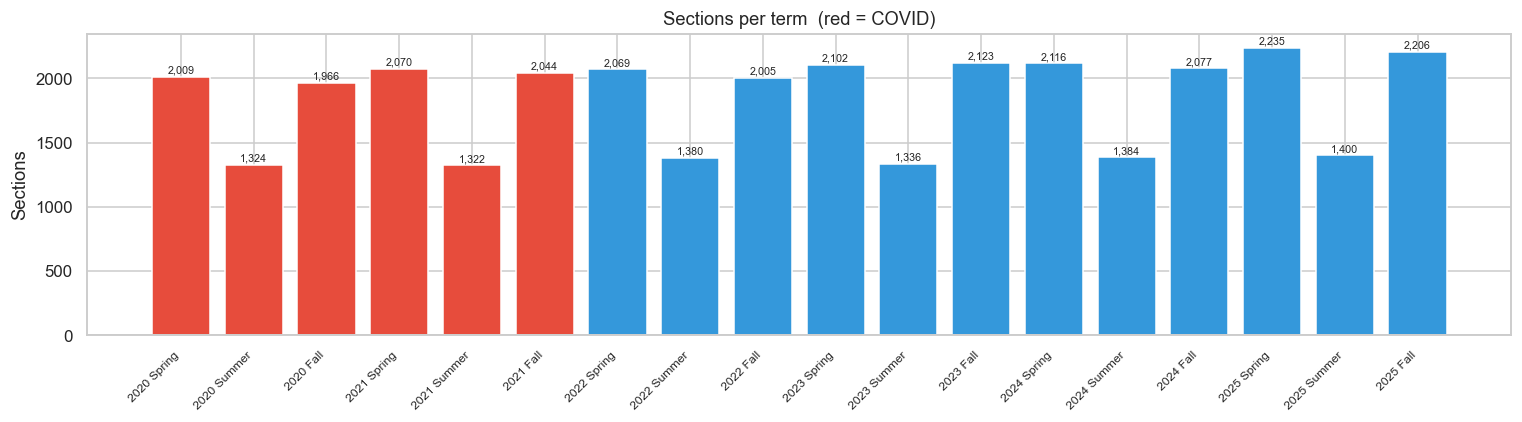

In [14]:
by_term = (
    df.groupby(['year', 'term_order', 'term', 'is_covid_affected'])
    .size()
    .reset_index(name='n')
    .sort_values(['year', 'term_order'])
)
by_term['label'] = by_term['year'].astype(str) + ' ' + by_term['term'].str.capitalize()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#e74c3c' if c else '#3498db' for c in by_term['is_covid_affected']]
bars = ax.bar(range(len(by_term)), by_term['n'], color=colors, edgecolor='white')
ax.set_xticks(range(len(by_term)))
ax.set_xticklabels(by_term['label'], rotation=45, ha='right', fontsize=8)
ax.set_title('Sections per term  (red = COVID)')
ax.set_ylabel('Sections')
for bar, val in zip(bars, by_term['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=7)
plt.tight_layout()
plt.savefig(FIG_PATH / '05_sections_per_term.png', dpi=150, bbox_inches='tight')
plt.show()

### Block 1 findings

- Shape: 33,168 rows  x  18 cols after cleaning
- Duplicates: 0 exact, 0 logical
- Different patterns: as in graphs above.
- COVID terms vs normal: identical counts ->  **COVID did not reduce offerings**.

---
## Block 2 — Missing data

In [15]:
# data is clean — the only remaining nullable column is instructor
# everything else was filtered in 01_cleaning.ipynb
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
pd.DataFrame({'count': null_counts, '%': null_pct})[null_counts > 0]

,count,%
instructor,5360,16.16
degree_level,315,0.95
title,16,0.05


In [16]:
# instructor nulls — which terms have the most unassigned sections?
instr_null = df[df['instructor'].isna() | (df['instructor'].str.strip() == '')]
print(f'no instructor: {len(instr_null):,}  ({len(instr_null)/len(df)*100:.1f}%)')
print()
print(instr_null.groupby(['year','term']).size().sort_values(ascending=False).head(10))

no instructor: 5,360  (16.2%)

year  term  
2022  fall      340
2023  fall      340
2021  spring    331
      fall      327
2024  fall      321
2023  spring    312
2022  spring    310
2020  spring    295
2024  summer    295
2022  summer    293
dtype: int64


In [17]:
# which departments have the most missing instructors?
(
    instr_null
    .groupby('dept_code')
    .size()
    .sort_values(ascending=False)
    .head(15)
)

dept_code
INLG    398
BUS     295
EDUC    291
BISC    286
PSYC    262
BPK     218
CA      171
ENSC    171
REM     168
POL     161
INS     155
MBB     148
GERO    148
ARCH    146
GEOG    145
dtype: int64

In [18]:
# campus breakdown — Burnaby / Surrey / Vancouver
df['campus'].value_counts(dropna=False)

campus
Burnaby             21074
Off-campus           3802
Surrey               3454
Harbour Ctr          3252
Other Vancouver      1394
Great North. Way      192
Name: count, dtype: int64

In [19]:
# degree level: UGRD vs GRAD
df['degree_level'].value_counts(dropna=False)

degree_level
UGRD    22356
GRAD    10497
None      315
Name: count, dtype: int64

In [20]:
# top 20 departments by section count
(
    df.groupby('dept_code')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

dept_code
BUS     3839
EDUC    2482
CMPT    2007
HSCI    1275
PSYC    1274
CA      1065
IAT     1006
CMNS     964
CRIM     930
BISC     910
ECON     853
ENSC     820
BPK      804
MATH     803
MBB      787
CHEM     728
INLG     726
MSE      704
LING     661
POL      634
dtype: int64

In [21]:
# course level distribution — 100/200/300/400/500+
df['course_level'].value_counts(bins=[0,199,299,399,499,9999]).sort_index()

(-0.001, 199.0]     3481
(199.0, 299.0]      4017
(299.0, 399.0]      7166
(399.0, 499.0]      7886
(499.0, 9999.0]    10618
Name: count, dtype: int64

### Block 2 findings

Graphs and patterns as above.

---
## Block 3 — Correlation analysis
Three periods: all data / COVID era / post-COVID.
Targets: `capacity` and `enrolled`.
Method: Pearson.
Sections with `enrolled = 0` are excluded here — no meaningful relationship to measure.

In [22]:
corr_df = df[df['enrolled'] > 0].copy()

corr_df['is_online'] = (corr_df['section_code'].str[0] != 'D').astype(int)
corr_df['is_summer'] = (corr_df['term'] == 'summer').astype(int)
corr_df['is_spring'] = (corr_df['term'] == 'spring').astype(int)

covid_rows     = corr_df[corr_df['is_covid_affected'] == 1]
postcovid_rows = corr_df[corr_df['is_covid_affected'] == 0]

FEATURES = ['course_level', 'year', 'term_order', 'is_covid_affected', 'is_online', 'is_summer', 'is_spring']
TARGETS  = ['capacity', 'enrolled']

print(f'rows for correlation (enrolled > 0): {len(corr_df):,}')
print(f'covid:                               {len(covid_rows):,}')
print(f'post-covid:                          {len(postcovid_rows):,}')

rows for correlation (enrolled > 0): 33,168
covid:                               10,735
post-covid:                          22,433


In [23]:
def correlations(data, features, targets):
    return pd.DataFrame({
        target: {
            feat: data[[feat, target]].dropna().corr(method='pearson').iloc[0, 1]
            for feat in features
        }
        for target in targets
    }).round(3)

corr_all   = correlations(corr_df,       FEATURES, TARGETS)
corr_covid = correlations(covid_rows,    FEATURES, TARGETS)
corr_post  = correlations(postcovid_rows, FEATURES, TARGETS)

print('ALL DATA')
print(corr_all)

ALL DATA
                   capacity  enrolled
course_level          -0.42     -0.44
year                  -0.02     -0.03
term_order             0.03      0.03
is_covid_affected      0.02      0.03
is_online             -0.27     -0.28
is_summer             -0.04     -0.06
is_spring             -0.01      0.00


In [24]:
print('COVID ERA (2020-2021)')
print(corr_covid)

COVID ERA (2020-2021)
                   capacity  enrolled
course_level          -0.43     -0.45
year                   0.00     -0.01
term_order             0.03      0.03
is_covid_affected       NaN       NaN
is_online             -0.27     -0.28
is_summer             -0.02     -0.03
is_spring             -0.01     -0.01


In [25]:
print('POST-COVID (2022-2025)')
print(corr_post)

POST-COVID (2022-2025)
                   capacity  enrolled
course_level          -0.42     -0.43
year                  -0.01     -0.01
term_order             0.02      0.03
is_covid_affected       NaN       NaN
is_online             -0.26     -0.28
is_summer             -0.05     -0.08
is_spring             -0.00      0.01


In [26]:
# combined table: all three periods side by side
# easier to read than a chart for three-period comparison
comparison = pd.concat([
    corr_all.add_suffix('_all'),
    corr_covid.add_suffix('_covid'),
    corr_post.add_suffix('_postcovid')
], axis=1)

# reorder: group by target
comparison = comparison[[
    'capacity_all', 'capacity_covid', 'capacity_postcovid',
    'enrolled_all', 'enrolled_covid', 'enrolled_postcovid'
]]
comparison

,capacity_all,capacity_covid,capacity_postcovid,enrolled_all,enrolled_covid,enrolled_postcovid
course_level,-0.42,-0.43,-0.42,-0.44,-0.45,-0.43
year,-0.02,0.00,-0.01,-0.03,-0.01,-0.01
term_order,0.03,0.03,0.02,0.03,0.03,0.03
is_covid_affected,0.02,NaN,NaN,0.03,NaN,NaN
is_online,-0.27,-0.27,-0.26,-0.28,-0.28,-0.28
is_summer,-0.04,-0.02,-0.05,-0.06,-0.03,-0.08
is_spring,-0.01,-0.01,-0.00,0.00,-0.01,0.01


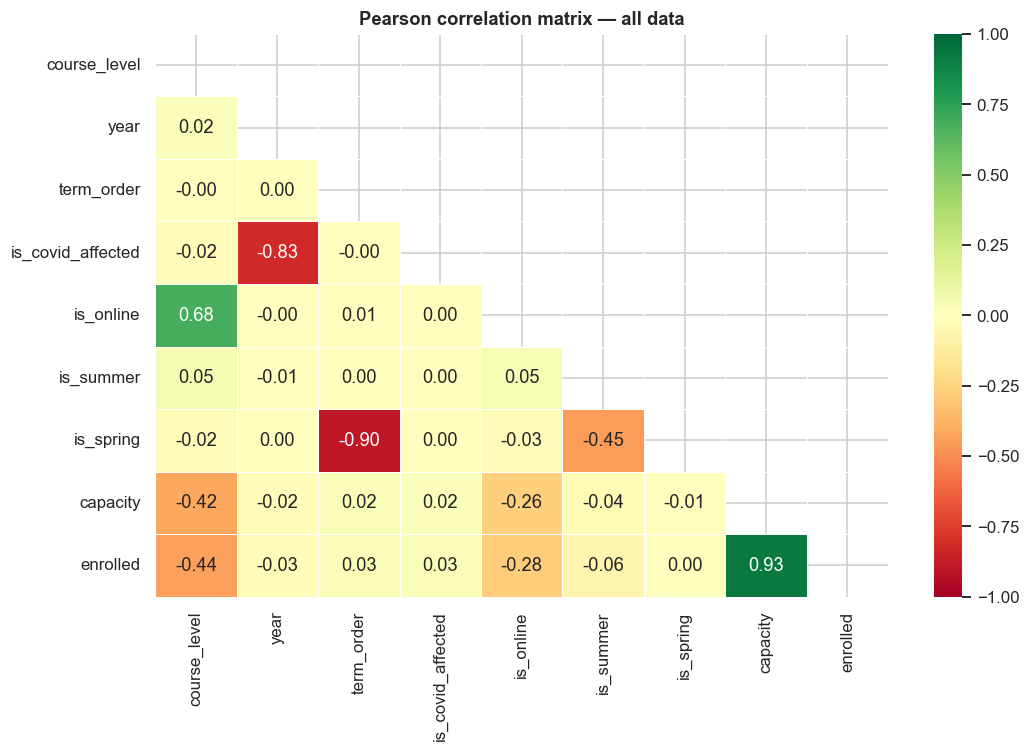

In [27]:
heat_data   = corr_df[FEATURES + TARGETS].dropna()
corr_matrix = heat_data.corr(method='pearson')
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Pearson correlation matrix — all data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / '07_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
divergence = (corr_covid - corr_post).abs().round(3)
print('|COVID corr - post-COVID corr|')
print(divergence)
print()
print(f'max divergence: {divergence.max().max():.3f}')

|COVID corr - post-COVID corr|
                   capacity  enrolled
course_level           0.01      0.02
year                   0.01      0.01
term_order             0.00      0.00
is_covid_affected       NaN       NaN
is_online              0.01      0.01
is_summer              0.03      0.06
is_spring              0.01      0.02

max divergence: 0.057


---
## Done
All figures saved to `notebooks/figures/`.

In [29]:
for f in sorted(FIG_PATH.glob('*.png')):
    print(f.name)

01_capacity.png
02_enrolled.png
03_delivery_mode.png
04_fill_rate.png
05_sections_per_term.png
07_heatmap.png
